# Figures — Anthropic / Eloundou

Replication and extension of key charts from the Anthropic Economic Index.

## Figure 1 · Share of Claude usage by Eloundou et al. exposure rating

Eloundou rows         : 19,265
Task penetration rows : 17,998

Claude-used tasks (penetration != 0) : 1,354

Diagnostics after merge:
  Total Claude-used tasks : 1,354
  Matched to beta      : 1,354
  Unmatched (no beta  ): 0  (0.0%)

Share of Claude-used tasks by beta bucket:
    Beta     Count     Share
  ----------------------------
     0.0         0      0.0%
     0.5       894     66.0%
     1.0       460     34.0%
   TOTAL     1,354    100.0%


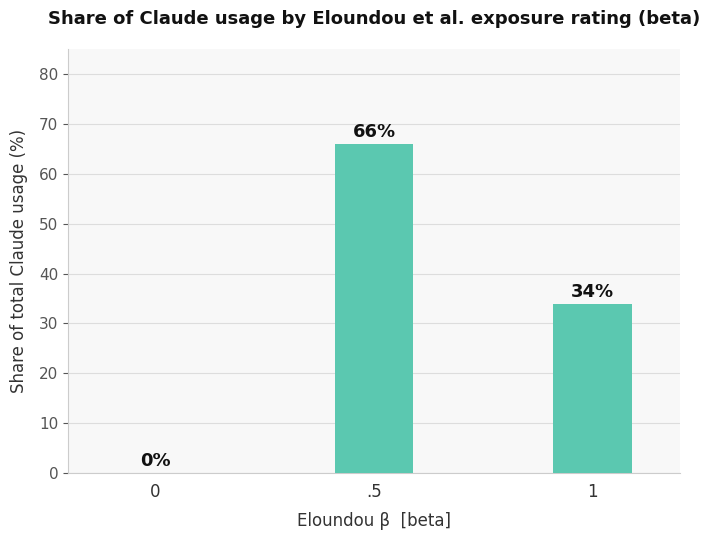


Figure saved: /Users/nicobagnoli/Documents/PYTHON/Standard-Analysis-Nico/SMP500/Anthropic/fig1_claude_usage_by_eloundou_beta.png


In [26]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

BASE             = Path("/Users/nicobagnoli/Documents/PYTHON/Standard-Analysis-Nico/SMP500")
ELOUNDOU_PATH    = BASE / "Eloundou_New" / "full_labelset_new.tsv"
PENETRATION_PATH = BASE / "Anthropic" / "task_penetration.csv"

# ── Switch between "beta" and "beta_new" (or any other column) here ──────────
BETA_COL = "beta"   # options: "beta", "beta_new"

OUTPUT_FIG = BASE / "Anthropic" / f"fig1_claude_usage_by_eloundou_{BETA_COL}.png"

# ── Load files ────────────────────────────────────────────────────────────────
df_eloundou = pd.read_csv(ELOUNDOU_PATH, sep="\t", low_memory=False)
df_penet    = pd.read_csv(PENETRATION_PATH)

print(f"Eloundou rows         : {len(df_eloundou):,}")
print(f"Task penetration rows : {len(df_penet):,}")

# ── Identify Claude-used tasks (penetration != 0) ─────────────────────────────
df_used = df_penet[df_penet["penetration"] != 0].copy()
print(f"\nClaude-used tasks (penetration != 0) : {len(df_used):,}")

# ── Keep one beta per unique task text in the Eloundou file ───────────────────
# (some tasks appear in multiple occupations — take the first occurrence, beta is task-level)
df_beta = (
    df_eloundou[["Task", BETA_COL]]
    .drop_duplicates(subset=["Task"])
    .rename(columns={"Task": "task"})
)

# ── Normalise whitespace before merging ──────────────────────────────────────
df_used["task"] = df_used["task"].astype(str).str.strip()
df_beta["task"] = df_beta["task"].astype(str).str.strip()

# ── Merge Claude-used tasks with beta ─────────────────────────────────────────
df_merged = df_used.merge(df_beta, on="task", how="left")

n_total     = len(df_merged)
n_matched   = df_merged[BETA_COL].notna().sum()
n_unmatched = n_total - n_matched

print(f"\nDiagnostics after merge:")
print(f"  Total Claude-used tasks : {n_total:,}")
print(f"  Matched to {BETA_COL:<10}: {n_matched:,}")
print(f"  Unmatched (no {BETA_COL:<6}): {n_unmatched:,}  "
      f"({100 * n_unmatched / n_total:.1f}%)")

# ── Drop unmatched, group by beta bucket ──────────────────────────────────────
df_matched = df_merged.dropna(subset=[BETA_COL]).copy()
df_matched["beta_bucket"] = df_matched[BETA_COL].round(1)   # 0.0, 0.5, 1.0

bucket_counts = (
    df_matched.groupby("beta_bucket")
    .size()
    .reindex([0.0, 0.5, 1.0], fill_value=0)
    .rename("count")
)
bucket_pct = (bucket_counts / bucket_counts.sum() * 100).rename("pct")

print(f"\nShare of Claude-used tasks by {BETA_COL} bucket:")
print(f"  {'Beta':>6}  {'Count':>8}  {'Share':>8}")
print("  " + "-" * 28)
for b in [0.0, 0.5, 1.0]:
    print(f"  {b:>6.1f}  {int(bucket_counts[b]):>8,}  {bucket_pct[b]:>7.1f}%")
print(f"  {'TOTAL':>6}  {int(bucket_counts.sum()):>8,}  {'100.0%':>8}")

# ── Plot ──────────────────────────────────────────────────────────────────────
TEAL   = "#5BC8B0"
LABELS = ["0", ".5", "1"]
X      = np.array([0.0, 0.5, 1.0])
Y      = [bucket_pct[b] for b in X]

fig, ax = plt.subplots(figsize=(7, 5.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F8F8")

bars = ax.bar(X, Y, width=0.18, color=TEAL, zorder=3)

# Percentage labels above bars
for bar, val in zip(bars, Y):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.6,
        f"{val:.0f}%",
        ha="center", va="bottom",
        fontsize=13, fontweight="bold", color="#111111"
    )

# Axes labels and title
ax.set_title(
    f"Share of Claude usage by Eloundou et al. exposure rating ({BETA_COL})",
    fontsize=13, fontweight="bold", pad=18, color="#111111"
)
ax.set_xlabel(f"Eloundou \u03b2  [{BETA_COL}]", fontsize=12, labelpad=8, color="#333333")
ax.set_ylabel("Share of total Claude usage (%)", fontsize=12, labelpad=8, color="#333333")

# X ticks at exactly 0, 0.5, 1
ax.set_xticks(X)
ax.set_xticklabels(LABELS, fontsize=12, color="#333333")
ax.set_xlim(-0.2, 1.2)

# Y axis
ax.set_ylim(0, 85)
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax.tick_params(axis="y", labelsize=11, colors="#555555")

# Horizontal grid lines, no spines on top/right
ax.yaxis.grid(True, color="#DDDDDD", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")
ax.tick_params(axis="x", bottom=False)

plt.tight_layout()
# plt.savefig(OUTPUT_FIG, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nFigure saved: {OUTPUT_FIG}")

# ── E0 tasks used by Claude (beta == 0, penetration != 0) ────────────────────
# e0_claude = df_matched[df_matched["beta"] == 0.0][["task", "penetration"]].copy()
# e0_claude = e0_claude.sort_values("penetration", ascending=False).reset_index(drop=True)
# e0_claude.index += 1

# print(f"E0 tasks used by Claude: {len(e0_claude):,}\n")
# print(e0_claude.to_string())


Eloundou rows              : 19,265
Unique Eloundou tasks      : 17,992
Using beta column          : beta
Claude use-case filter     : work
API treatment              : all task-level occurrences

Claude AI · Aug  (aei_raw_claude_ai_2025-08-04_to_2025-08-11.csv)
  Filter used                 : Claude fallback to all use cases via onet_task + onet_task_count
  Unique tasks after filter   : 2,616
  Tasks matched to beta      : 2,209
  Tasks unmatched             : 408
  Matched count mass          : 728,852.00
  Unmatched count mass        : 158,099.00
    β=0.0: raw_count=34,277.00   share=4.7%
    β=0.5: raw_count=279,048.00   share=38.3%
    β=1.0: raw_count=415,527.00   share=57.0%

1P API · Aug  (aei_raw_1p_api_2025-08-04_to_2025-08-11.csv)
  Filter used                 : API all task-level occurrences via onet_task + onet_task_count
  Unique tasks after filter   : 2,054
  Tasks matched to beta      : 1,739
  Tasks unmatched             : 316
  Matched count mass          : 678,352.

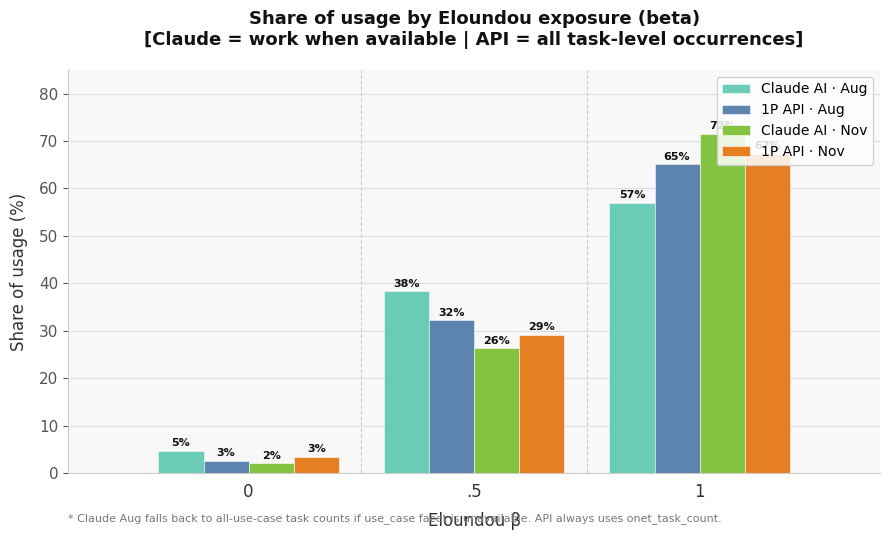

Figure saved: /Users/nicobagnoli/Documents/PYTHON/Standard-Analysis-Nico/SMP500/Anthropic/fig_4files_beta_work_corrected.png

Claude AI · Aug: pooled raw counts β=[0: 34,277.00   .5: 279,048.00   1: 415,527.00]
1P API · Aug: pooled raw counts β=[0: 17,987.00   .5: 218,995.00   1: 441,370.00]
Claude AI · Nov: pooled raw counts β=[0: 7,491.00   .5: 92,504.00   1: 250,951.00]
1P API · Nov: pooled raw counts β=[0: 24,384.00   .5: 205,093.00   1: 472,807.00]

Combined share across all 4 sources:
  β=0.0: raw_count=84,139.00   share=3.4%
  β=0.5: raw_count=795,640.00   share=32.3%
  β=1.0: raw_count=1,580,655.00   share=64.2%


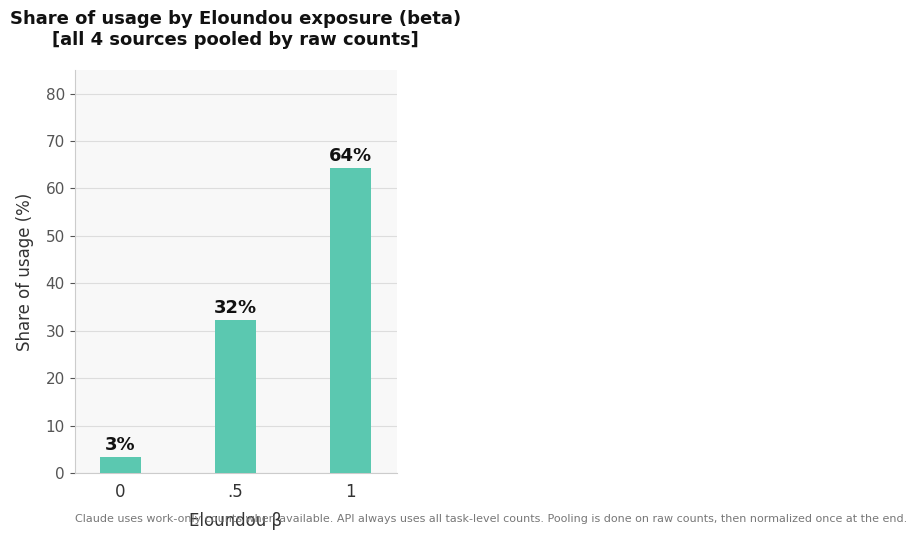


Figure saved: /Users/nicobagnoli/Documents/PYTHON/Standard-Analysis-Nico/SMP500/Anthropic/fig_combined_beta_work_corrected.png


In [27]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────
BASE = Path("/Users/nicobagnoli/Documents/PYTHON/Standard-Analysis-Nico/SMP500")
ELOUNDOU_PATH = BASE / "Eloundou_New" / "full_labelset_new.tsv"

BETA_COL = "beta"
GEO_ID   = "GLOBAL"
USE_CASE = "work"   # used only for Claude AI
OUTPUT_FIG = BASE / "Anthropic" / f"fig_4files_{BETA_COL}_{USE_CASE}_corrected.png"
OUTPUT_FIG_COMBINED = BASE / "Anthropic" / f"fig_combined_{BETA_COL}_{USE_CASE}_corrected.png"

# ── Four source files ─────────────────────────────────────────────────
SOURCES = [
    {
        "label":  "Claude AI · Aug",
        "path":   BASE / "Anthropic" / "aei_raw_claude_ai_2025-08-04_to_2025-08-11.csv",
        "period": "Aug 2025",
        "kind":   "claude",
    },
    {
        "label":  "1P API · Aug",
        "path":   BASE / "Anthropic" / "aei_raw_1p_api_2025-08-04_to_2025-08-11.csv",
        "period": "Aug 2025",
        "kind":   "api",
    },
    {
        "label":  "Claude AI · Nov",
        "path":   BASE / "Anthropic" / "aei_raw_claude_ai_2025-11-13_to_2025-11-20.csv",
        "period": "Nov 2025",
        "kind":   "claude",
    },
    {
        "label":  "1P API · Nov",
        "path":   BASE / "Anthropic" / "aei_raw_1p_api_2025-11-13_to_2025-11-20 (1).csv",
        "period": "Nov 2025",
        "kind":   "api",
    },
]

# ── Eloundou beta lookup ──────────────────────────────────────────────
df_eloundou = pd.read_csv(ELOUNDOU_PATH, sep="\t", low_memory=False)
df_beta = (
    df_eloundou[["Task", BETA_COL]]
    .drop_duplicates(subset=["Task"])
    .rename(columns={"Task": "task"})
)
df_beta["task"] = df_beta["task"].astype(str).str.strip().str.lower()

print(f"Eloundou rows              : {len(df_eloundou):,}")
print(f"Unique Eloundou tasks      : {len(df_beta):,}")
print(f"Using beta column          : {BETA_COL}")
print(f"Claude use-case filter     : {USE_CASE}")
print(f"API treatment              : all task-level occurrences\n")


# ── Helper: load usage rows correctly as COUNTS ───────────────────────
def extract_task_counts(path, geo_id, source_kind, use_case):
    df = pd.read_csv(path)

    if "platform_and_product" in df.columns:
        if source_kind == "claude":
            df = df[df["platform_and_product"] == "Claude AI (Free and Pro)"].copy()
        elif source_kind == "api":
            df = df[df["platform_and_product"] == "1P API"].copy()

    if "geo_id" in df.columns:
        df = df[df["geo_id"] == geo_id].copy()

    if source_kind == "claude":
        # Prefer work-only if the intersection facet exists
        has_uc = (df["facet"] == "onet_task::use_case").any()
        if has_uc:
            out = df[
                (df["facet"] == "onet_task::use_case") &
                (df["variable"] == "onet_task_use_case_count") &
                (df["cluster_name"].astype(str).str.endswith(f"::{use_case}"))
            ].copy()

            out["task"] = out["cluster_name"].astype(str).str.rsplit("::", n=1).str[0]
            out = out.rename(columns={"value": "count"})[["task", "count"]]
            note = f"Claude filtered to use_case={use_case} via onet_task::use_case + onet_task_use_case_count"
        else:
            out = df[
                (df["facet"] == "onet_task") &
                (df["variable"] == "onet_task_count")
            ].copy()

            out = out.rename(columns={"cluster_name": "task", "value": "count"})[["task", "count"]]
            note = "Claude fallback to all use cases via onet_task + onet_task_count"
    else:
        # API always uses all task-level occurrences, as requested
        out = df[
            (df["facet"] == "onet_task") &
            (df["variable"] == "onet_task_count")
        ].copy()

        out = out.rename(columns={"cluster_name": "task", "value": "count"})[["task", "count"]]
        note = "API all task-level occurrences via onet_task + onet_task_count"

    out["task"] = out["task"].astype(str).str.strip().str.lower()
    out["count"] = pd.to_numeric(out["count"], errors="coerce")
    out = out.dropna(subset=["task", "count"]).copy()

    # Drop privacy / placeholder categories if present
    out = out[~out["task"].isin(["not_classified", "none"])].copy()

    # Aggregate in case a task appears more than once after filtering
    out = out.groupby("task", as_index=False)["count"].sum()

    return out, note


# ── Helper: merge to beta and compute beta-bucket shares ──────────────
def compute_beta_shares_from_counts(task_counts, beta_lookup, beta_col):
    df_m = task_counts.merge(beta_lookup, on="task", how="left")

    matched_tasks = df_m[beta_col].notna().sum()
    unmatched_tasks = df_m[beta_col].isna().sum()
    matched_count_mass = df_m.loc[df_m[beta_col].notna(), "count"].sum()
    unmatched_count_mass = df_m.loc[df_m[beta_col].isna(), "count"].sum()

    df_m = df_m.dropna(subset=[beta_col]).copy()
    df_m["beta_bucket"] = pd.to_numeric(df_m[beta_col], errors="coerce").round(1)
    df_m = df_m[df_m["beta_bucket"].isin([0.0, 0.5, 1.0])].copy()

    raw_counts = (
        df_m.groupby("beta_bucket")["count"]
        .sum()
        .reindex([0.0, 0.5, 1.0], fill_value=0.0)
    )

    share = raw_counts / raw_counts.sum() * 100 if raw_counts.sum() > 0 else raw_counts.copy()

    diagnostics = {
        "tasks_total": len(task_counts),
        "tasks_matched": int(matched_tasks),
        "tasks_unmatched": int(unmatched_tasks),
        "count_mass_matched": float(matched_count_mass),
        "count_mass_unmatched": float(unmatched_count_mass),
        "raw_counts": raw_counts,
        "share": share,
    }
    return diagnostics


# ── Compute for all four files ────────────────────────────────────────
for src in SOURCES:
    print(f"{src['label']}  ({src['path'].name})")
    task_counts, note = extract_task_counts(src["path"], GEO_ID, src["kind"], USE_CASE)
    diag = compute_beta_shares_from_counts(task_counts, df_beta, BETA_COL)

    src["note"] = note
    src["task_counts"] = task_counts
    src["diag"] = diag
    src["share"] = diag["share"]
    src["raw_counts"] = diag["raw_counts"]

    print(f"  Filter used                 : {note}")
    print(f"  Unique tasks after filter   : {diag['tasks_total']:,}")
    print(f"  Tasks matched to {BETA_COL:<10}: {diag['tasks_matched']:,}")
    print(f"  Tasks unmatched             : {diag['tasks_unmatched']:,}")
    print(f"  Matched count mass          : {diag['count_mass_matched']:,.2f}")
    print(f"  Unmatched count mass        : {diag['count_mass_unmatched']:,.2f}")
    for b in [0.0, 0.5, 1.0]:
        print(
            f"    β={b:.1f}: raw_count={diag['raw_counts'][b]:,.2f}   share={diag['share'][b]:.1f}%"
        )
    print()


# ── Plot 1: four files side by side ───────────────────────────────────
COLORS = ["#5BC8B0", "#4C78A8", "#82C341", "#E67E22"]

X = np.array([0.0, 0.5, 1.0])
n = len(SOURCES)
width = 0.10
offsets = np.linspace(-(n - 1) * width / 2, (n - 1) * width / 2, n)

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F8F8")

for i, src in enumerate(SOURCES):
    bars = ax.bar(
        X + offsets[i],
        src["share"].values,
        width=width,
        color=COLORS[i],
        label=src["label"],
        zorder=3,
        alpha=0.9 if "Aug" in src["label"] else 1.0,
        edgecolor="white",
        linewidth=0.4,
    )
    for bar in bars:
        h = bar.get_height()
        if h > 1:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.5,
                f"{h:.0f}%",
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="bold",
                color="#111111",
            )

for xv in [0.25, 0.75]:
    ax.axvline(xv, color="#CCCCCC", linewidth=0.8, linestyle="--", zorder=0)

ax.set_title(
    f"Share of usage by Eloundou exposure ({BETA_COL})\n"
    f"[Claude = {USE_CASE} when available | API = all task-level occurrences]",
    fontsize=13,
    fontweight="bold",
    pad=18,
    color="#111111",
)
ax.set_xlabel("Eloundou \u03b2", fontsize=12, labelpad=8, color="#333333")
ax.set_ylabel("Share of usage (%)", fontsize=12, labelpad=8, color="#333333")

ax.set_xticks(X)
ax.set_xticklabels(["0", ".5", "1"], fontsize=12, color="#333333")
ax.set_xlim(-0.4, 1.4)

ax.set_ylim(0, 85)
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax.tick_params(axis="y", labelsize=11, colors="#555555")

ax.yaxis.grid(True, color="#DDDDDD", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")
ax.tick_params(axis="x", bottom=False)

ax.legend(fontsize=10, loc="upper right", framealpha=0.85)

ax.annotate(
    "* Claude Aug falls back to all-use-case task counts if use_case facet is unavailable. "
    "API always uses onet_task_count.",
    xy=(0, -0.1), xycoords="axes fraction",
    fontsize=8, color="#777777", va="top"
)

plt.tight_layout()
#plt.savefig(OUTPUT_FIG, dpi=180, bbox_inches="tight")
plt.show()

print(f"Figure saved: {OUTPUT_FIG}\n")


# ── Plot 2: pooled across all four sources, correctly weighted by counts ─────
combined_raw = pd.Series([0.0, 0.0, 0.0], index=[0.0, 0.5, 1.0])

for src in SOURCES:
    combined_raw = combined_raw.add(src["raw_counts"], fill_value=0)
    print(
        f"{src['label']}: pooled raw counts β=[0: {src['raw_counts'][0.0]:,.2f}   "
        f".5: {src['raw_counts'][0.5]:,.2f}   1: {src['raw_counts'][1.0]:,.2f}]"
    )

combined_share = combined_raw / combined_raw.sum() * 100 if combined_raw.sum() > 0 else combined_raw.copy()

print("\nCombined share across all 4 sources:")
for b in [0.0, 0.5, 1.0]:
    print(f"  β={b:.1f}: raw_count={combined_raw[b]:,.2f}   share={combined_share[b]:.1f}%")


TEAL = "#5BC8B0"

fig, ax = plt.subplots(figsize=(7, 5.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F8F8")

bars = ax.bar(X, combined_share.values, width=0.18, color=TEAL, zorder=3)

for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.6,
            f"{h:.0f}%",
            ha="center",
            va="bottom",
            fontsize=13,
            fontweight="bold",
            color="#111111",
        )

ax.set_title(
    f"Share of usage by Eloundou exposure ({BETA_COL})\n"
    f"[all 4 sources pooled by raw counts]",
    fontsize=13,
    fontweight="bold",
    pad=18,
    color="#111111",
)
ax.set_xlabel("Eloundou \u03b2", fontsize=12, labelpad=8, color="#333333")
ax.set_ylabel("Share of usage (%)", fontsize=12, labelpad=8, color="#333333")

ax.set_xticks(X)
ax.set_xticklabels(["0", ".5", "1"], fontsize=12, color="#333333")
ax.set_xlim(-0.2, 1.2)

ax.set_ylim(0, 85)
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax.tick_params(axis="y", labelsize=11, colors="#555555")

ax.yaxis.grid(True, color="#DDDDDD", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")
ax.tick_params(axis="x", bottom=False)

ax.annotate(
    "Claude uses work-only counts when available. API always uses all task-level counts. "
    "Pooling is done on raw counts, then normalized once at the end.",
    xy=(0, -0.1), xycoords="axes fraction",
    fontsize=8, color="#777777", va="top"
)

plt.tight_layout()
#plt.savefig(OUTPUT_FIG_COMBINED, dpi=180, bbox_inches="tight")
plt.show()

print(f"\nFigure saved: {OUTPUT_FIG_COMBINED}")